In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv("/content/titanic.csv")

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [6]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,0,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [7]:
df.columns #getting to know columns names

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [9]:
df.describe() #mathematical summary of data for understanding the data better

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [10]:
df.isnull().sum()   #for finding count of null values, helps us understand data better

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


In [11]:
df.duplicated().sum()     #for finding duplicated values

np.int64(0)

In [12]:
df["Name"] = df["Name"].str.strip()  #removes trailing and leading spaces in data
df["Name"] = df["Name"].str.title()  #makes the txt from males/Males/maLES to Males fromat for cleaner data
df["Sex"] = df["Sex"].str.strip()
df["Sex"] = df["Sex"].str.title()

In [13]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",Male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",Female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",Male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",Male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",Female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",Male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva Y Ocana, Dona. Fermina",Female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",Male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",Male,NaN,0,0,359309,8.0500,NaN,S


In [14]:
df = df.drop(columns=["Cabin"])     #dropping cabin since 327 values out of 412 are null and is not relevant for our analysis

In [15]:
df["Age"] = df["Age"].fillna(df["Age"].median())  #filling missing age value with the median value
df["Fare"] = df["Fare"].fillna(df["Fare"].mean()) #filling missing fare value with the mean value

In [16]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,0,3,"Kelly, Mr. James",Male,34.5,0,0,330911,7.8292,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",Female,47.0,1,0,363272,7.0000,S
2,894,0,2,"Myles, Mr. Thomas Francis",Male,62.0,0,0,240276,9.6875,Q
3,895,0,3,"Wirz, Mr. Albert",Male,27.0,0,0,315154,8.6625,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",Female,22.0,1,1,3101298,12.2875,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",Male,27.0,0,0,A.5. 3236,8.0500,S
414,1306,1,1,"Oliva Y Ocana, Dona. Fermina",Female,39.0,0,0,PC 17758,108.9000,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",Male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,S
416,1308,0,3,"Ware, Mr. Frederick",Male,27.0,0,0,359309,8.0500,S


In [17]:
df.isnull().sum() # no null values now

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [18]:
df.to_csv("titanic_cleaned.csv", index=False)   #savning the clean data

Doing EDA - Exploratory Data Analysis

In [19]:
df = pd.read_csv("titanic_cleaned.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,0,3,"Kelly, Mr. James",Male,34.5,0,0,330911,7.8292,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",Female,47.0,1,0,363272,7.0000,S
2,894,0,2,"Myles, Mr. Thomas Francis",Male,62.0,0,0,240276,9.6875,Q
3,895,0,3,"Wirz, Mr. Albert",Male,27.0,0,0,315154,8.6625,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",Female,22.0,1,1,3101298,12.2875,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",Male,27.0,0,0,A.5. 3236,8.0500,S
414,1306,1,1,"Oliva Y Ocana, Dona. Fermina",Female,39.0,0,0,PC 17758,108.9000,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",Male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,S
416,1308,0,3,"Ware, Mr. Frederick",Male,27.0,0,0,359309,8.0500,S


Survival Count

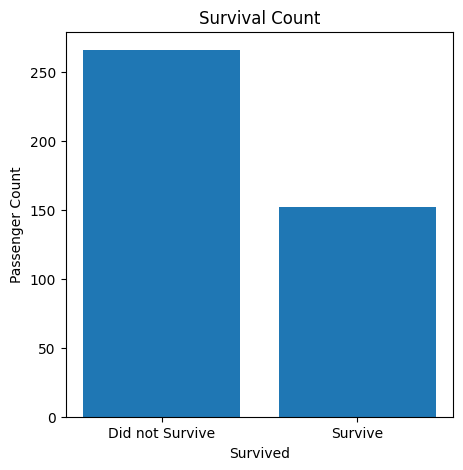

In [20]:
plt.figure(figsize=(5,5))
plt.bar(df["Survived"].value_counts().index,
        df["Survived"].value_counts().values)

plt.xlabel("Survived")
plt.xticks([0,1],["Did not Survive","Survive"] )
plt.ylabel("Passenger Count")
plt.title("Survival Count")
plt.show()

Gender Distribution


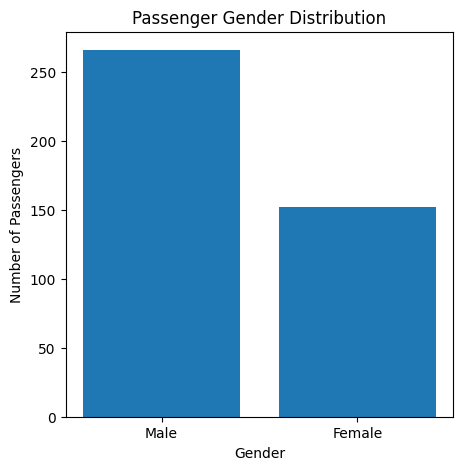

In [21]:
plt.figure(figsize = (5,5))
plt.bar(df["Sex"].value_counts().index,
        df["Sex"].value_counts().values)
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.title("Passenger Gender Distribution")
plt.show()


Age Distribution

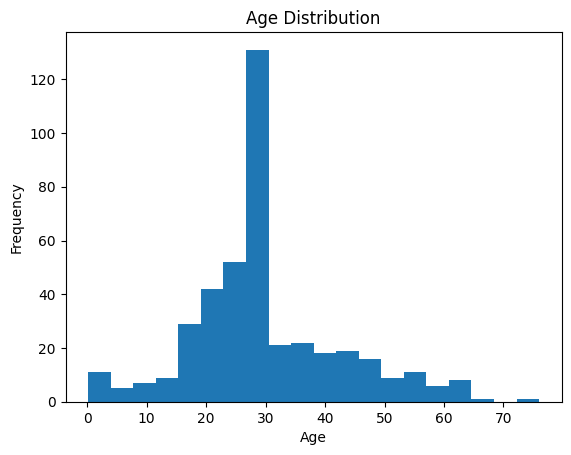

In [22]:
plt.hist(df["Age"], bins = 20)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

Survival by Passenger Class

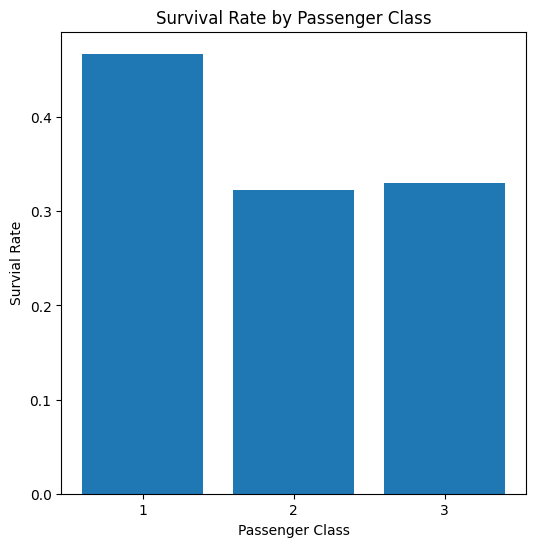

In [23]:
survival = df.groupby("Pclass")["Survived"].mean()
plt.figure(figsize=(6,6))
plt.bar(survival.index, survival.values)
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survial Rate")
plt.xticks([1,2,3])
plt.show()

Insight from above graph = Passengers travelling in first class had a significantly higher survival rate than those in second and third class. This suggests that passenger class was an important factor influencing survival.

Survival Rate by Gender

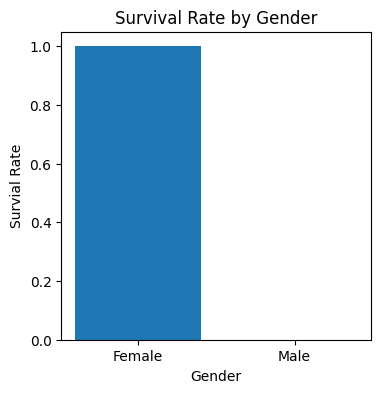

In [24]:
survival_gender = df.groupby("Sex")["Survived"].mean()
plt.figure(figsize=(4,4))
plt.bar(survival_gender.index, survival_gender.values)
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survial Rate")
plt.show()